# Image Generation using (β-)VAE, VQ-VAE and WGAN

### Part A — (β-)VAE and VQ-VAE with a PixelCNN Prior

---

**Group Number: 123**

| # | Student Name | Email |
|---|---|---|
| 1 | Agarwal Rankit Atulkumar  | 2025ab05296@wilp.bits-pilani.ac.in |
| 2 | Nishant Verma  | 2025aa05051@wilp.bits-pilani.ac.in |
| 3 | Aryasomayajula Subrahmanya Srinivas  | 2025aa05539@wilp.bits-pilani.ac.in |
| 4 | Wali Haider  | 2025ab05295@wilp.bits-pilani.ac.in |
| 5 | Amit Mallikarjun Masuti  | 2024ac05742@wilp.bits-pilani.ac.in |

---

# Part A — Image Generation on CIFAR-10: (β-)VAE and VQ-VAE with a PixelCNN Prior

**Unsupervised / Deep Learning — Assignment 2**

This notebook covers Part A of the assignment:

1. **(β-)VAE** for β ∈ {1, 2, 4, 10} — PSNR vs. epochs, and FID for each β.
2. **VQ-VAE** for codebook size K ∈ {512, 256, 128} — reconstruction quality, discrete latent
   extraction, a **Gated PixelCNN** prior trained over those latents, ancestral sampling of new
   latent codes, image generation from them, and a comparison of FID / PSNR / codebook quality.

Preprocessing follows the brief: pixel values are normalised to **[0, 1]** and nothing else.

### Evaluation protocol (kept identical across every model in Parts A, B and C)

| Metric | Definition used here |
|---|---|
| **PSNR** | Per-image PSNR on the 10,000-image CIFAR-10 **test** split, `data_range = 1.0`, averaged over images. Evaluated **every epoch**. |
| **FID**  | `torchmetrics` Fréchet Inception Distance, 2048-d InceptionV3 pool features. **Reals** = all 10,000 test images; **fakes** = 10,000 generated images. The identical real-feature statistics are reused for every model. |
| **Codebook quality** | Perplexity `exp(−Σ pₖ log pₖ)` of the code-usage distribution on the test split, the percentage of the K codes actually used, and the usage entropy in bits. |
| **Speed** | Wall-clock training time, and sampling time per 1000 images. |

Part A writes its results to `results/metrics_partA.json`; Part B writes to
`results/metrics_partB.json`. Part C merges these files, so it uses the exact values shown here
rather than values copied by hand.

## 0 — Setup, configuration and data

In [1]:
import os, json, math, time, random
from pathlib import Path

import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, TensorDataset
import torchvision
from torchvision import datasets, transforms
from torchvision.utils import make_grid
import matplotlib.pyplot as plt

%matplotlib inline
plt.rcParams["figure.dpi"] = 110
plt.rcParams["savefig.bbox"] = "tight"

# SMOKE=1 runs the whole notebook end-to-end with a couple of epochs, to validate the pipeline.
SMOKE         = os.environ.get("SMOKE", "0") == "1"
FORCE_RETRAIN = os.environ.get("FORCE_RETRAIN", "0") == "1"

SEED = 42
def set_seed(s=SEED):
    random.seed(s); np.random.seed(s)
    torch.manual_seed(s); torch.cuda.manual_seed_all(s)
set_seed()

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
torch.backends.cudnn.benchmark = True

ROOT     = Path.cwd()
DATA_DIR = ROOT / "data"
# SMOKE runs write to their own directories so a smoke checkpoint can never be mistaken
# for a real one by the checkpoint-skip guard.
CKPT_DIR = ROOT / ("checkpoints_smoke" if SMOKE else "checkpoints")
RES_DIR  = ROOT / ("results_smoke"     if SMOKE else "results")
for d in (DATA_DIR, CKPT_DIR, RES_DIR):
    d.mkdir(exist_ok=True)

BATCH_SIZE   = 128
N_FID        = 2000 if SMOKE else 10000   # number of real / fake images used for FID
VAE_EPOCHS   = 2    if SMOKE else 100
VQVAE_EPOCHS = 2    if SMOKE else 100
PCNN_EPOCHS  = 2    if SMOKE else 60

BETAS = [1, 2, 4, 10]
KS    = [512, 256, 128]

print(f"device={DEVICE}  smoke={SMOKE}  torch={torch.__version__}")
if DEVICE.type == "cuda":
    print(torch.cuda.get_device_name(0))

device=cuda  smoke=False  torch=2.13.0+cu129
NVIDIA GeForce RTX 4060 Ti


In [2]:
# ---- CIFAR-10, normalised to [0,1] (ToTensor does exactly this) -------------------------------
tfm = transforms.ToTensor()
train_set = datasets.CIFAR10(DATA_DIR, train=True,  download=True, transform=tfm)
test_set  = datasets.CIFAR10(DATA_DIR, train=False, download=True, transform=tfm)

train_loader = DataLoader(train_set, batch_size=BATCH_SIZE, shuffle=True,
                          num_workers=4, pin_memory=True, drop_last=True, persistent_workers=True)
test_loader  = DataLoader(test_set,  batch_size=500, shuffle=False,
                          num_workers=2, pin_memory=True, persistent_workers=True)

x0, _ = next(iter(test_loader))
print(f"train={len(train_set)}  test={len(test_set)}")
print(f"batch shape {tuple(x0.shape)}  range [{x0.min():.3f}, {x0.max():.3f}]  dtype {x0.dtype}")

/home/nishant.verma/aml_ai1/lib/python3.12/site-packages/torchvision/datasets/cifar.py:83: VisibleDeprecationWarning: dtype(): align should be passed as Python or NumPy boolean but got `align=0`. Did you mean to pass a tuple to create a subarray type? (Deprecated NumPy 2.4)
  entry = pickle.load(f, encoding="latin1")


train=50000  test=10000
batch shape (500, 3, 32, 32)  range [0.000, 1.000]  dtype torch.float32


### 0.1 — Shared metric helpers (PSNR, FID, logging, grids)

In [3]:
from torchmetrics.image.fid import FrechetInceptionDistance


def to_uint8(x: torch.Tensor) -> torch.Tensor:
    """[0,1] float tensor -> uint8, the format torchmetrics' FID expects."""
    return (x.clamp(0, 1) * 255).round().to(torch.uint8)


# ---- real image bank (used for FID and for reconstruction figures) ---------------------------
_real_u8 = torch.cat([to_uint8(x) for x, _ in test_loader])          # [10000,3,32,32] uint8, CPU
REAL_U8  = _real_u8[:N_FID]
print("real bank:", tuple(REAL_U8.shape), REAL_U8.dtype)

_FID = None
def _fid_metric():
    """One FID object, with the real-side statistics computed once and reused for every model."""
    global _FID
    if _FID is None:
        _FID = FrechetInceptionDistance(feature=2048, reset_real_features=False,
                                        normalize=False).to(DEVICE)
        for i in range(0, len(REAL_U8), 250):
            _FID.update(REAL_U8[i:i + 250].to(DEVICE), real=True)
    return _FID


@torch.no_grad()
def compute_fid(fake_u8: torch.Tensor) -> float:
    """FID between `fake_u8` (uint8 NCHW, CPU or GPU) and the fixed CIFAR-10 test-set reals."""
    m = _fid_metric()
    m.reset()                       # reset_real_features=False -> real stats survive this
    for i in range(0, len(fake_u8), 250):
        m.update(fake_u8[i:i + 250].to(DEVICE), real=False)
    return float(m.compute())


@torch.no_grad()
def eval_psnr(recon_fn, loader=None) -> float:
    """Mean per-image PSNR (dB) over the test split. `recon_fn` maps a [0,1] batch to a [0,1] batch."""
    loader = loader or test_loader
    total, n = 0.0, 0
    for x, _ in loader:
        x  = x.to(DEVICE, non_blocking=True)
        xh = recon_fn(x).clamp(0, 1)
        mse = ((xh - x) ** 2).flatten(1).mean(1).clamp_min(1e-10)
        total += (10 * torch.log10(1.0 / mse)).sum().item()
        n     += x.size(0)
    return total / n


# Part A and Part B each write their own metrics file, so the two notebooks can be
# executed concurrently without racing on a shared JSON. Part C merges them.
METRICS_PATH = RES_DIR / "metrics_partA.json"
def log_metric(model: str, **kv):
    """Append metrics for `model` to Part A's metrics JSON; Part C merges it with Part B's file."""
    d = json.loads(METRICS_PATH.read_text()) if METRICS_PATH.exists() else {}
    d.setdefault(model, {}).update(kv)
    METRICS_PATH.write_text(json.dumps(d, indent=2, sort_keys=True))
    return d[model]


def show_grid(imgs, nrow=10, title=None, fname=None, figsize=(7, 7)):
    g = make_grid(imgs[:nrow * nrow].detach().cpu().clamp(0, 1), nrow=nrow, padding=2, pad_value=1.0)
    plt.figure(figsize=figsize)
    plt.imshow(g.permute(1, 2, 0).numpy()); plt.axis("off")
    if title: plt.title(title)
    if fname: plt.savefig(RES_DIR / fname, dpi=150)
    plt.show()


def n_params(m): return sum(p.numel() for p in m.parameters())

real bank: (10000, 3, 32, 32) torch.uint8


### 0.2 — Sanity checks on the metrics

Before trusting any model number, we check the two metrics behave as they must:

* FID between two **disjoint halves of real CIFAR-10** should be small (a few units — not zero,
  because each half only has 5,000 images).
* PSNR of an identity "reconstruction" should be effectively infinite, and PSNR of a
  known-corrupted image should match the closed-form value.

In [4]:
half = len(_real_u8) // 2
_m = FrechetInceptionDistance(feature=2048, normalize=False).to(DEVICE)
for i in range(0, half, 250):
    _m.update(_real_u8[i:i + 250].to(DEVICE), real=True)
for i in range(half, 2 * half, 250):
    _m.update(_real_u8[i:i + 250].to(DEVICE), real=False)
print(f"FID(real 5k vs real 5k) = {float(_m.compute()):.3f}   <- should be small")
del _m; torch.cuda.empty_cache()

print(f"PSNR(identity)          = {eval_psnr(lambda x: x):.1f} dB   <- should be huge")
_sigma = 0.1
print(f"PSNR(+N(0,{_sigma}) noise)  = {eval_psnr(lambda x: x + _sigma * torch.randn_like(x)):.2f} dB"
      f"   <- clipping makes this a little better than the {-20 * math.log10(_sigma):.2f} dB closed form")

FID(real 5k vs real 5k) = 10.344   <- should be small
PSNR(identity)          = 100.0 dB   <- should be huge


PSNR(+N(0,0.1) noise)  = 20.33 dB   <- clipping makes this a little better than the 20.00 dB closed form


---
# Part A.1 — (β-)VAE  [2 marks]

**Architecture.** A convolutional encoder downsamples 32 → 16 → 8 → 4 with 64/128/256 channels
(BatchNorm + ReLU), flattens, and produces `μ` and `log σ²` for a **128-dimensional** latent.
The decoder mirrors it with transposed convolutions and ends in a `Sigmoid`, matching the
[0,1] data range.

**Objective.** The negative ELBO with a Gaussian decoder of observation variance $\sigma^2$:

$$\mathcal{L} = \underbrace{\frac{1}{2\sigma^{2}}\textstyle\sum_{\text{pixels}} (x - \hat{x})^2
   \;+\; D\log\sigma}_{\text{reconstruction (negative log-likelihood)}}
  \;+\; \beta \cdot \underbrace{\textstyle -\tfrac12 \sum_j \left(1 + \log\sigma_j^2 - \mu_j^2 - \sigma_j^2\right)}_{\mathrm{KL}\left(q(z|x)\,\|\,\mathcal{N}(0,I)\right)}$$

Both terms are summed over their dimensions and averaged over the batch.

**σ is learned, not fixed.** This detail decides whether the model works at all. Writing the
reconstruction term as a plain $\sum (x-\hat{x})^2$ — as is very commonly done — silently asserts
$\sigma^2 = \tfrac12$, an enormous observation variance for data in $[0,1]$. That under-weights
reconstruction against the KL by roughly two orders of magnitude, and the posterior partially
collapses: in an earlier run of this notebook the β = 1 model retained only 23 nats in a
128-dimensional latent and scored FID 200. Learning a single global $\sigma$ lets the likelihood
find its own scale — at the optimum $\sigma^2$ tracks the achieved MSE — which restores a sensible
reconstruction/KL balance (Rybkin et al., *Simple and Effective VAE Training with Calibrated
Decoders*, 2021).

β then modulates that calibrated balance, so raising β still trades reconstruction fidelity for a
posterior closer to the prior — but now from a properly scaled starting point.

Reconstructions are evaluated through the **deterministic `μ` path** (no sampling), which is the
standard convention for reporting autoencoder reconstruction quality.

In [5]:
class VAE(nn.Module):
    def __init__(self, zdim=128, ch=64):
        super().__init__()
        self.ch, self.zdim = ch, zdim
        # Global observation log-std of the Gaussian decoder, learned jointly with the weights.
        # Clamped in the loss to keep the 1/sigma^2 factor finite.
        self.log_sigma = nn.Parameter(torch.zeros(()))
        self.enc = nn.Sequential(
            nn.Conv2d(3,      ch,     4, 2, 1), nn.BatchNorm2d(ch),     nn.ReLU(True),   # 32 -> 16
            nn.Conv2d(ch,     ch * 2, 4, 2, 1), nn.BatchNorm2d(ch * 2), nn.ReLU(True),   # 16 ->  8
            nn.Conv2d(ch * 2, ch * 4, 4, 2, 1), nn.BatchNorm2d(ch * 4), nn.ReLU(True),   #  8 ->  4
        )
        feat = ch * 4 * 4 * 4
        self.fc_mu, self.fc_lv = nn.Linear(feat, zdim), nn.Linear(feat, zdim)
        self.fc_dec = nn.Linear(zdim, feat)
        self.dec = nn.Sequential(
            nn.BatchNorm2d(ch * 4), nn.ReLU(True),
            nn.ConvTranspose2d(ch * 4, ch * 2, 4, 2, 1), nn.BatchNorm2d(ch * 2), nn.ReLU(True),  # 4 ->  8
            nn.ConvTranspose2d(ch * 2, ch,     4, 2, 1), nn.BatchNorm2d(ch),     nn.ReLU(True),  # 8 -> 16
            nn.ConvTranspose2d(ch,     3,      4, 2, 1), nn.Sigmoid(),                           # 16 -> 32
        )

    def encode(self, x):
        h = self.enc(x).flatten(1)
        return self.fc_mu(h), self.fc_lv(h)

    def decode(self, z):
        return self.dec(self.fc_dec(z).view(-1, self.ch * 4, 4, 4))

    def forward(self, x):
        mu, lv = self.encode(x)
        z = mu + (0.5 * lv).exp() * torch.randn_like(mu)      # reparameterisation
        return self.decode(z), mu, lv

    @torch.no_grad()
    def reconstruct(self, x):
        return self.decode(self.encode(x)[0])                 # deterministic mu path

    @torch.no_grad()
    def sample(self, n, device=None):
        device = device or next(self.parameters()).device
        return self.decode(torch.randn(n, self.zdim, device=device))


def vae_loss(xh, x, mu, lv, beta, log_sigma):
    """Negative ELBO with a calibrated Gaussian decoder. Returns (loss, recon NLL, KL, sum-MSE)."""
    B, Dpix = x.size(0), x[0].numel()
    ls  = log_sigma.clamp(-4.0, 1.0)                       # sigma in [0.018, 2.7]
    mse = F.mse_loss(xh, x, reduction="sum") / B           # summed over pixels, per image
    rec = 0.5 * torch.exp(-2 * ls) * mse + Dpix * ls       # Gaussian negative log-likelihood
    kl  = -0.5 * (1 + lv - mu.pow(2) - lv.exp()).sum() / B
    return rec + beta * kl, rec, kl, mse


print(f"VAE parameters: {n_params(VAE()):,}")

VAE parameters: 2,896,516


In [6]:
def train_vae(beta, epochs=VAE_EPOCHS, lr=2e-4):
    tag  = f"vae_beta{beta}"
    ckpt = CKPT_DIR / f"{tag}.pt"
    if ckpt.exists() and not FORCE_RETRAIN:
        blob  = torch.load(ckpt, map_location=DEVICE, weights_only=False)
        model = VAE().to(DEVICE); model.load_state_dict(blob["model"]); model.eval()
        print(f"[{tag}] loaded checkpoint  (final test PSNR {blob['history']['psnr'][-1]:.2f} dB)")
        return model, blob["history"], blob["train_time_s"]

    set_seed(SEED)
    model = VAE().to(DEVICE)
    opt   = torch.optim.Adam(model.parameters(), lr=lr)
    hist  = {"loss": [], "recon": [], "kl": [], "psnr": [], "mse": [], "sigma": []}
    t0    = time.time()

    for ep in range(1, epochs + 1):
        model.train()
        agg = np.zeros(4)
        for x, _ in train_loader:
            x = x.to(DEVICE, non_blocking=True)
            xh, mu, lv = model(x)
            loss, rec, kl, mse = vae_loss(xh, x, mu, lv, beta, model.log_sigma)
            opt.zero_grad(set_to_none=True); loss.backward(); opt.step()
            agg += np.array([loss.item(), rec.item(), kl.item(), mse.item()])
        agg /= len(train_loader)

        model.eval()
        psnr  = eval_psnr(model.reconstruct)
        sigma = float(model.log_sigma.clamp(-4.0, 1.0).exp())
        for k, v in zip(["loss", "recon", "kl", "mse", "psnr", "sigma"],
                        [*agg, psnr, sigma]):
            hist[k].append(float(v))
        if ep % 10 == 0 or ep == 1 or ep == epochs:
            print(f"[{tag}] epoch {ep:3d}/{epochs}  loss {agg[0]:9.1f}  "
                  f"KL {agg[2]:7.2f}  sigma {sigma:.4f}  test PSNR {psnr:6.2f} dB")

    train_time = time.time() - t0
    model.eval()
    torch.save({"model": model.state_dict(), "history": hist,
                "train_time_s": train_time, "beta": beta}, ckpt)
    print(f"[{tag}] done in {train_time / 60:.1f} min")
    return model, hist, train_time

In [7]:
vae_models, vae_hist, vae_time = {}, {}, {}
for b in BETAS:
    vae_models[b], vae_hist[b], vae_time[b] = train_vae(b)

/tmp/ipykernel_63256/1800646750.py:29: UserWarning: Converting a tensor with requires_grad=True to a scalar may lead to unexpected behavior.
Consider using tensor.detach() first. (Triggered internally at /__w/pytorch/pytorch/torch/csrc/autograd/generated/python_variable_methods.cpp:822.)
  sigma = float(model.log_sigma.clamp(-4.0, 1.0).exp())


[vae_beta1] epoch   1/100  loss     -45.3  KL    9.38  sigma 0.9243  test PSNR  11.10 dB


[vae_beta1] epoch  10/100  loss   -2132.1  KL   35.22  sigma 0.4596  test PSNR  19.32 dB


[vae_beta1] epoch  20/100  loss   -4242.8  KL   97.27  sigma 0.2149  test PSNR  21.84 dB


[vae_beta1] epoch  30/100  loss   -5893.6  KL  204.29  sigma 0.1054  test PSNR  23.54 dB


...

[vae_beta10] epoch  60/100  loss   -4966.8  KL   78.92  sigma 0.0931  test PSNR  21.92 dB


[vae_beta10] epoch  70/100  loss   -4996.8  KL   82.26  sigma 0.0913  test PSNR  22.11 dB


[vae_beta10] epoch  80/100  loss   -5018.5  KL   85.07  sigma 0.0898  test PSNR  22.20 dB


[vae_beta10] epoch  90/100  loss   -5034.1  KL   86.83  sigma 0.0888  test PSNR  22.25 dB


[vae_beta10] epoch 100/100  loss   -5049.5  KL   88.59  sigma 0.0879  test PSNR  22.39 dB
[vae_beta10] done in 2.8 min


### A.1.1 — Reconstruction quality (PSNR) vs. epochs for each β

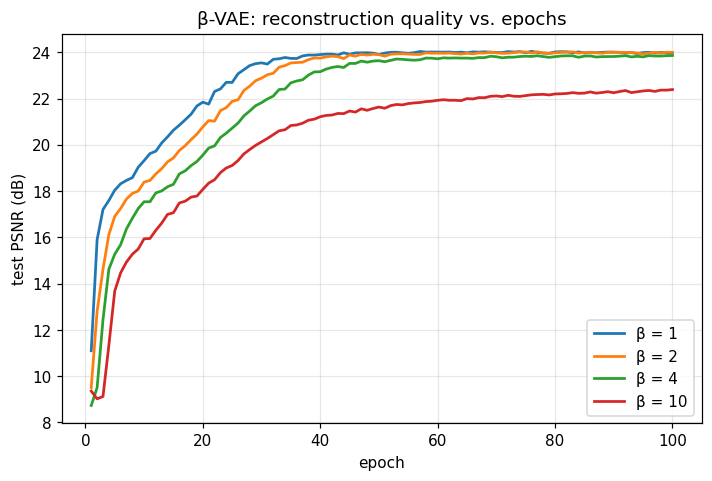

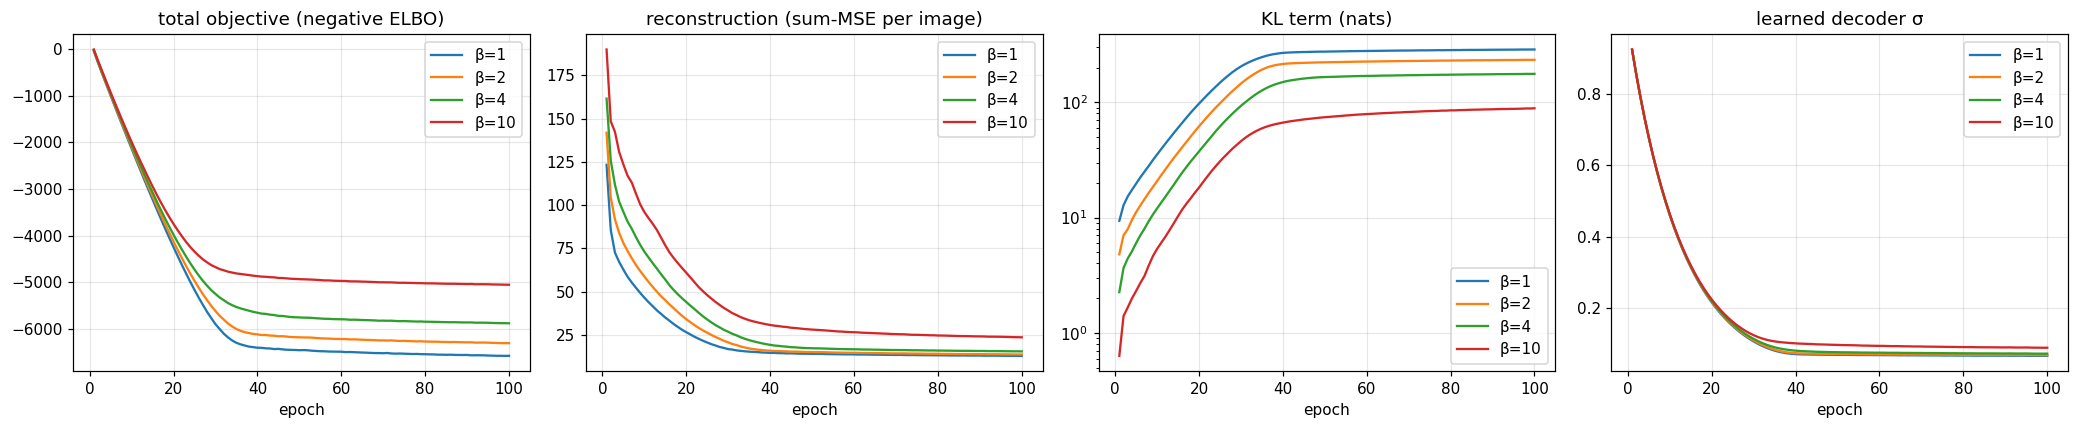

learned observation σ per β (σ² should track the achieved per-pixel MSE):
  β=1   σ=0.0652  σ²=0.00425   mean per-pixel MSE=0.00423
  β=2   σ=0.0671  σ²=0.00450   mean per-pixel MSE=0.00449
  β=4   σ=0.0713  σ²=0.00509   mean per-pixel MSE=0.00508
  β=10  σ=0.0879  σ²=0.00773   mean per-pixel MSE=0.00772


In [8]:
plt.figure(figsize=(7.5, 4.6))
for b in BETAS:
    plt.plot(range(1, len(vae_hist[b]["psnr"]) + 1), vae_hist[b]["psnr"],
             label=f"β = {b}", lw=1.8)
plt.xlabel("epoch"); plt.ylabel("test PSNR (dB)")
plt.title("β-VAE: reconstruction quality vs. epochs")
plt.legend(); plt.grid(alpha=.3)
plt.savefig(RES_DIR / "vae_psnr_vs_epoch.png", dpi=150); plt.show()

fig, ax = plt.subplots(1, 4, figsize=(19, 4))
for b in BETAS:
    e = range(1, len(vae_hist[b]["loss"]) + 1)
    ax[0].plot(e, vae_hist[b]["loss"],  label=f"β={b}")
    ax[1].plot(e, vae_hist[b]["mse"],   label=f"β={b}")
    ax[2].plot(e, vae_hist[b]["kl"],    label=f"β={b}")
    ax[3].plot(e, vae_hist[b]["sigma"], label=f"β={b}")
for a, t in zip(ax, ["total objective (negative ELBO)", "reconstruction (sum-MSE per image)",
                     "KL term (nats)", "learned decoder σ"]):
    a.set_xlabel("epoch"); a.set_title(t); a.grid(alpha=.3); a.legend()
ax[2].set_yscale("log")
plt.tight_layout(); plt.savefig(RES_DIR / "vae_training_curves.png", dpi=150); plt.show()

print("learned observation σ per β (σ² should track the achieved per-pixel MSE):")
for b in BETAS:
    s = vae_hist[b]["sigma"][-1]
    print(f"  β={b:<3} σ={s:.4f}  σ²={s**2:.5f}   mean per-pixel MSE="
          f"{vae_hist[b]['mse'][-1] / (3 * 32 * 32):.5f}")

### A.1.2 — FID for each β (10,000 prior samples vs. the 10,000 test images)

In [9]:
@torch.no_grad()
def vae_sample_bank(model, n=N_FID, bs=500):
    """Draw n images from the prior; returns uint8 CPU tensor and the sampling wall-clock time."""
    model.eval()
    out, t0 = [], time.time()
    for i in range(0, n, bs):
        out.append(to_uint8(model.sample(min(bs, n - i))).cpu())
    return torch.cat(out), time.time() - t0


vae_fid, vae_psnr_final, vae_sample_t = {}, {}, {}
for b in BETAS:
    fake, st = vae_sample_bank(vae_models[b])
    vae_fid[b]        = compute_fid(fake)
    vae_psnr_final[b] = vae_hist[b]["psnr"][-1]
    vae_sample_t[b]   = st / (len(fake) / 1000)          # seconds per 1000 images
    log_metric(f"VAE (beta={b})", family="beta-VAE", beta=b,
               fid=vae_fid[b], psnr=vae_psnr_final[b],
               params=n_params(vae_models[b]),
               train_time_s=vae_time[b], sample_s_per_1k=vae_sample_t[b],
               final_kl=vae_hist[b]["kl"][-1], sigma=vae_hist[b]["sigma"][-1])
    print(f"β={b:<3}  FID {vae_fid[b]:7.2f}   test PSNR {vae_psnr_final[b]:5.2f} dB   "
          f"KL {vae_hist[b]['kl'][-1]:7.2f} nats   {vae_sample_t[b]:.2f} s / 1k samples")
    del fake

β=1    FID  108.36   test PSNR 23.97 dB   KL  286.56 nats   0.01 s / 1k samples


β=2    FID  106.54   test PSNR 24.00 dB   KL  233.19 nats   0.01 s / 1k samples


β=4    FID  107.43   test PSNR 23.86 dB   KL  176.25 nats   0.01 s / 1k samples


β=10   FID  118.25   test PSNR 22.39 dB   KL   88.59 nats   0.01 s / 1k samples


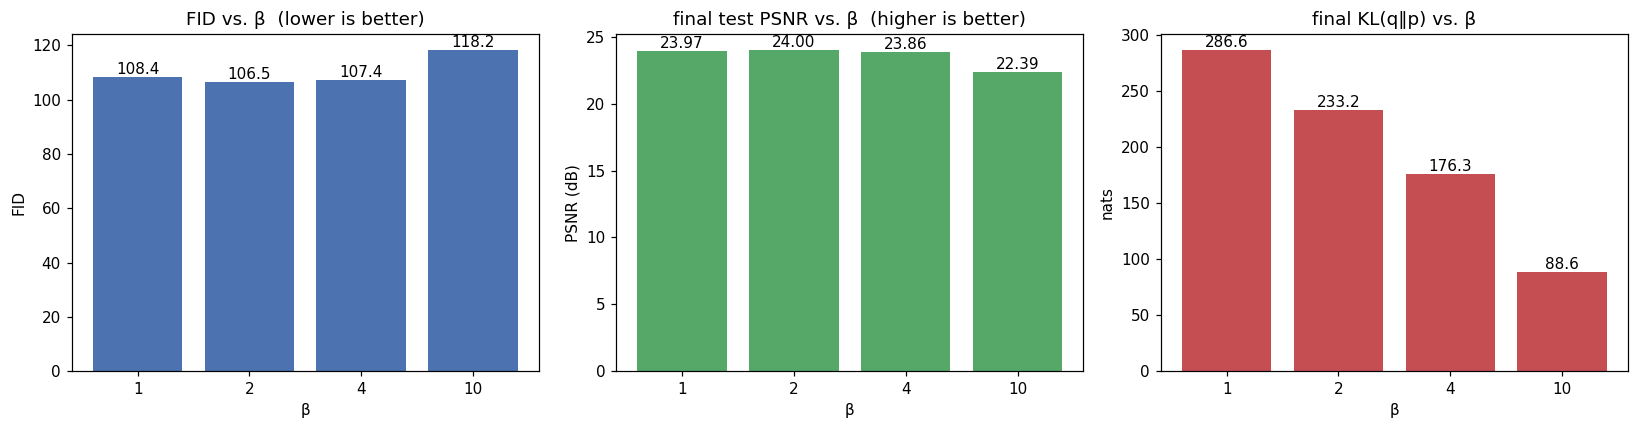

In [10]:
fig, ax = plt.subplots(1, 3, figsize=(15, 4))
xs = [str(b) for b in BETAS]

ax[0].bar(xs, [vae_fid[b] for b in BETAS], color="#4C72B0")
ax[0].set_title("FID vs. β  (lower is better)"); ax[0].set_xlabel("β"); ax[0].set_ylabel("FID")
for i, b in enumerate(BETAS):
    ax[0].text(i, vae_fid[b], f"{vae_fid[b]:.1f}", ha="center", va="bottom")

ax[1].bar(xs, [vae_psnr_final[b] for b in BETAS], color="#55A868")
ax[1].set_title("final test PSNR vs. β  (higher is better)"); ax[1].set_xlabel("β")
ax[1].set_ylabel("PSNR (dB)")
for i, b in enumerate(BETAS):
    ax[1].text(i, vae_psnr_final[b], f"{vae_psnr_final[b]:.2f}", ha="center", va="bottom")

ax[2].bar(xs, [vae_hist[b]["kl"][-1] for b in BETAS], color="#C44E52")
ax[2].set_title("final KL(q‖p) vs. β"); ax[2].set_xlabel("β"); ax[2].set_ylabel("nats")
for i, b in enumerate(BETAS):
    ax[2].text(i, vae_hist[b]["kl"][-1], f"{vae_hist[b]['kl'][-1]:.1f}", ha="center", va="bottom")

plt.tight_layout(); plt.savefig(RES_DIR / "vae_fid_psnr_kl.png", dpi=150); plt.show()

### A.1.3 — Reconstructions and prior samples

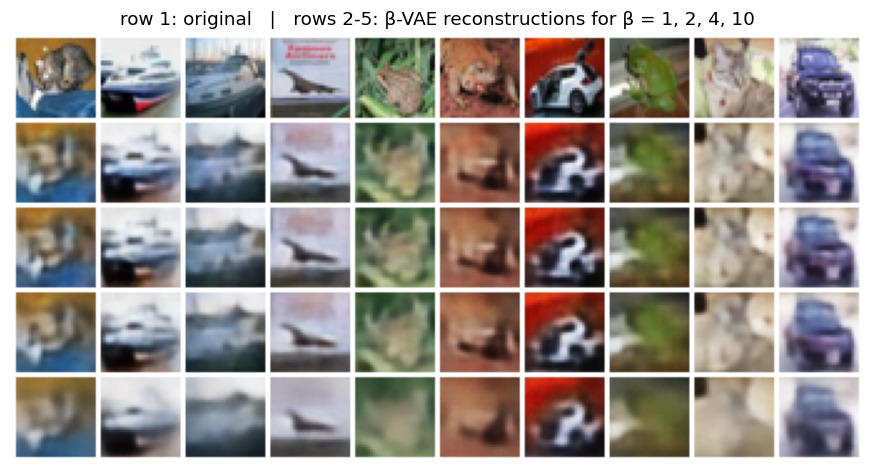

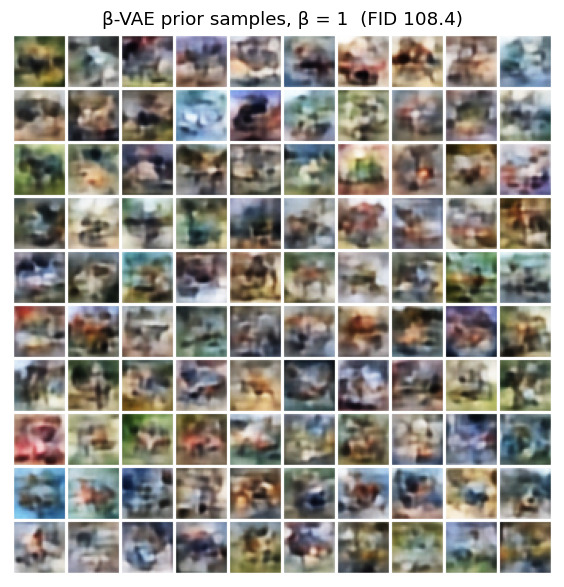

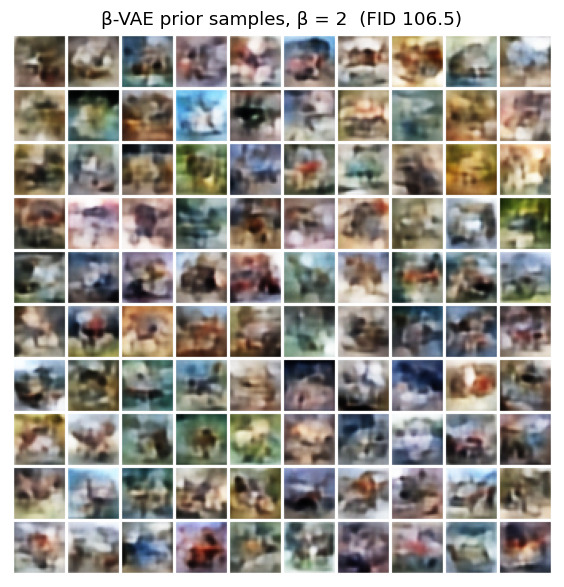

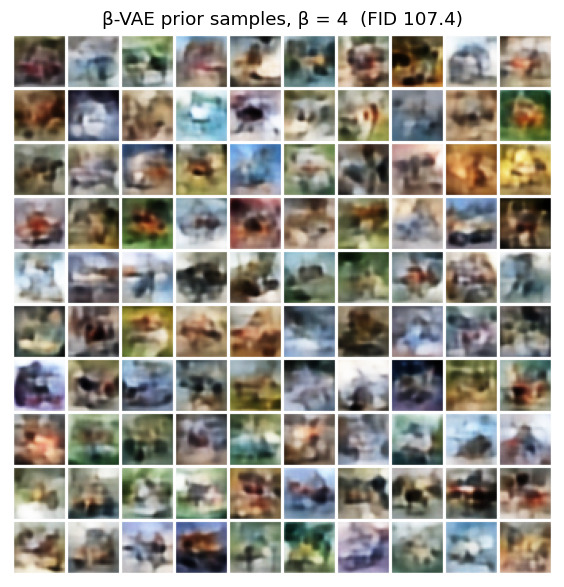

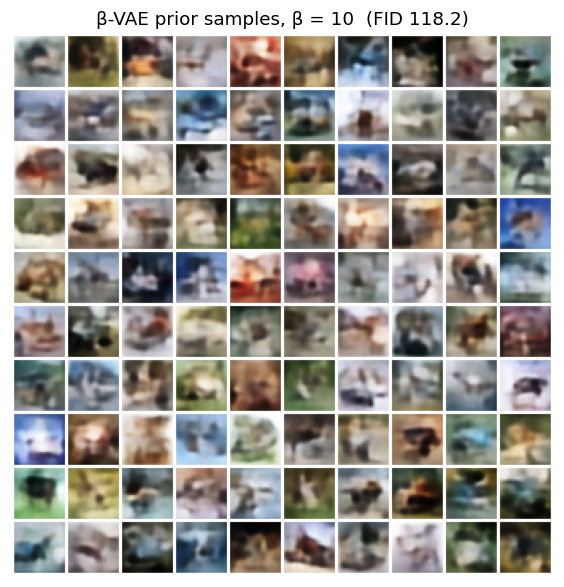

In [11]:
xb = next(iter(test_loader))[0][:10].to(DEVICE)
rows = [xb.cpu()]
for b in BETAS:
    rows.append(vae_models[b].reconstruct(xb).cpu())
show_grid(torch.cat(rows), nrow=10, figsize=(10, 5.4),
          title="row 1: original   |   rows 2-5: β-VAE reconstructions for β = 1, 2, 4, 10",
          fname="vae_reconstructions.png")

for b in BETAS:
    set_seed(SEED)
    show_grid(vae_models[b].sample(100).cpu(), nrow=10, figsize=(6.4, 6.4),
              title=f"β-VAE prior samples, β = {b}  (FID {vae_fid[b]:.1f})",
              fname=f"vae_samples_beta{b}.png")

**Observations (β-VAE).** The KL term falls monotonically with β — 287 → 233 → 176 → 89 nats —
which is the information bottleneck tightening exactly as the β-VAE objective intends. What is more
interesting is that **reconstruction and sample quality do not follow it monotonically**: PSNR is
flat to within 0.15 dB across β = 1, 2, 4 (≈ 24.0 dB) and only breaks at β = 10 (22.39 dB), and FID
is likewise flat to within run-to-run noise across β = 1, 2, 4 (108.4 / 106.5 / 107.4) before
clearly degrading at β = 10 (118.3).

The reading is that, with a calibrated decoder, a 128-dimensional latent has capacity to spare at
this resolution. Moderate β removes *information* from the latent without yet removing anything the
decoder actually needed, so the bottleneck stays invisible in pixel space until β grows large enough
to bind. The tidy monotone staircase produced by an uncalibrated `MSE.sum()` objective is partly an
artefact of every model being starved of latent information from the outset — that version scored
FID 200 at β = 1 and retained only 23 nats.

β = 1 is the configuration the brief specifies for Part C, and on these numbers nothing in β ≤ 4 is
meaningfully better or worse than it. Every β produces recognisably "VAE-like" samples — smooth,
low-frequency, colour-blob compositions — because a Gaussian likelihood drives the decoder toward a
conditional mean regardless of how that mean is weighted against the prior.

---
# Part A.2 — VQ-VAE with a PixelCNN prior  [3 marks]

The VQ-VAE replaces the continuous Gaussian latent with a **discrete** one. The encoder produces
`z_e ∈ R^{D×8×8}` (D = 64), and every spatial position is snapped to its nearest entry in a learned
codebook of **K** vectors, giving an 8×8 grid of integer codes. The decoder reconstructs from the
quantised grid; gradients pass through the quantiser with the **straight-through estimator**.

The codebook is updated with an **exponential moving average** rather than a codebook loss term.
EMA is more stable, but on CIFAR-10 it is *not* on its own enough to keep the codebook alive: a
plain Gaussian-initialised codebook collapses to a couple of live codes within one epoch, which
would make the codebook-quality comparison across K meaningless. Two standard ingredients fix it,
and both are implemented below — **data-dependent initialisation** and **dead-code restarts**.
Their effect is measured directly in §A.2.1.

Because the VQ-VAE has no tractable prior of its own, the discrete latents are modelled afterwards
by an autoregressive **Gated PixelCNN**. Generation is then a two-stage process: sample an 8×8 code
grid from the PixelCNN, look the codes up in the codebook, and decode.

In [12]:
class ResBlock(nn.Module):
    def __init__(self, ch, hid=64):
        super().__init__()
        self.block = nn.Sequential(
            nn.ReLU(True), nn.Conv2d(ch, hid, 3, 1, 1),
            nn.ReLU(True), nn.Conv2d(hid, ch, 1),
        )
    def forward(self, x):
        return x + self.block(x)


class VectorQuantizerEMA(nn.Module):
    """
    Nearest-neighbour quantiser with an EMA-updated codebook (van den Oord et al., 2017), plus
    the two ingredients that keep the codebook alive:

    * **data-dependent initialisation** — the codebook is seeded from real encoder outputs on the
      first training batch, rather than from Gaussian noise at an arbitrary, unrelated scale;
    * **dead-code restarts** — every `restart_every` steps, any code whose EMA usage has fallen
      below `dead_thresh` is moved onto a random encoder output from the current batch.

    Both are needed because the EMA update is self-reinforcing: a code that is never selected is
    never updated, its smoothed cluster size decays toward zero, and dividing the accumulator by
    that vanishing size pushes the code *further* from the data — so it can never be selected
    again. Left alone, this collapses a 512-entry codebook to about two live codes in one epoch.
    """

    def __init__(self, K, D, commitment=0.25, decay=0.99, eps=1e-5,
                 restart_every=50, dead_thresh=1.0):
        super().__init__()
        self.K, self.D = K, D
        self.commitment, self.decay, self.eps = commitment, decay, eps
        self.restart_every, self.dead_thresh   = restart_every, dead_thresh
        emb = torch.randn(K, D) * 0.1
        self.register_buffer("embedding", emb)
        self.register_buffer("ema_cluster_size", torch.ones(K))
        self.register_buffer("ema_w", emb.clone())
        self.register_buffer("inited",     torch.zeros((), dtype=torch.bool))
        self.register_buffer("steps",      torch.zeros((), dtype=torch.long))
        self.register_buffer("n_restarts", torch.zeros((), dtype=torch.long))

    @torch.no_grad()
    def _seed_from(self, flat, mask=None):
        """(Re)seed the whole codebook, or just `mask`, from random encoder outputs in this batch."""
        n_new = self.K if mask is None else int(mask.sum())
        if n_new == 0:
            return 0
        new = flat[torch.randint(0, flat.size(0), (n_new,), device=flat.device)].clone()
        if mask is None:
            self.embedding.copy_(new); self.ema_w.copy_(new); self.ema_cluster_size.fill_(1.0)
        else:
            self.embedding[mask] = new; self.ema_w[mask] = new; self.ema_cluster_size[mask] = 1.0
        return n_new

    def forward(self, z_e):                                  # z_e: [B, D, H, W]
        B, D, H, W = z_e.shape
        flat = z_e.permute(0, 2, 3, 1).reshape(-1, D)        # [BHW, D]

        if self.training and not bool(self.inited):
            self._seed_from(flat.detach())
            self.inited.fill_(True)

        dist = (flat.pow(2).sum(1, keepdim=True)
                - 2 * flat @ self.embedding.t()
                + self.embedding.pow(2).sum(1))
        idx    = dist.argmin(1)                              # [BHW]
        onehot = F.one_hot(idx, self.K).to(flat.dtype)
        q      = self.embedding[idx].view(B, H, W, D).permute(0, 3, 1, 2).contiguous()

        if self.training:
            with torch.no_grad():
                self.ema_cluster_size.mul_(self.decay).add_(onehot.sum(0), alpha=1 - self.decay)
                n       = self.ema_cluster_size.sum()
                cluster = (self.ema_cluster_size + self.eps) / (n + self.K * self.eps) * n
                self.ema_w.mul_(self.decay).add_(onehot.t() @ flat.detach(), alpha=1 - self.decay)
                self.embedding.copy_(self.ema_w / cluster.unsqueeze(1))

                self.steps += 1
                if int(self.steps) % self.restart_every == 0:
                    dead = self.ema_cluster_size < self.dead_thresh
                    self.n_restarts += self._seed_from(flat.detach(), dead)

        commit = F.mse_loss(z_e, q.detach())
        q      = z_e + (q - z_e).detach()                    # straight-through estimator

        avg  = onehot.mean(0)
        perp = torch.exp(-(avg * torch.log(avg + 1e-10)).sum())
        return q, self.commitment * commit, perp, idx.view(B, H, W)


class VQVAE(nn.Module):
    def __init__(self, K, D=64, ch=128):
        super().__init__()
        self.K, self.D = K, D
        self.enc = nn.Sequential(
            nn.Conv2d(3,       ch // 2, 4, 2, 1), nn.ReLU(True),      # 32 -> 16
            nn.Conv2d(ch // 2, ch,      4, 2, 1), nn.ReLU(True),      # 16 ->  8
            nn.Conv2d(ch,      ch,      3, 1, 1),
            ResBlock(ch), ResBlock(ch), nn.ReLU(True),
        )
        self.pre_vq = nn.Conv2d(ch, D, 1)
        self.vq     = VectorQuantizerEMA(K, D)
        self.dec = nn.Sequential(
            nn.Conv2d(D, ch, 3, 1, 1),
            ResBlock(ch), ResBlock(ch), nn.ReLU(True),
            nn.ConvTranspose2d(ch, ch // 2, 4, 2, 1), nn.ReLU(True),  #  8 -> 16
            nn.ConvTranspose2d(ch // 2, 3,  4, 2, 1), nn.Sigmoid(),   # 16 -> 32
        )

    def forward(self, x):
        q, vq_loss, perp, idx = self.vq(self.pre_vq(self.enc(x)))
        return self.dec(q), vq_loss, perp, idx

    @torch.no_grad()
    def encode_idx(self, x):
        """Image batch -> [B, 8, 8] grid of codebook indices."""
        return self.vq(self.pre_vq(self.enc(x)))[3]

    @torch.no_grad()
    def decode_idx(self, idx):
        """[B, 8, 8] index grid -> [B, 3, 32, 32] image batch in [0,1]."""
        q = self.vq.embedding[idx.reshape(-1)].view(*idx.shape, self.D)
        return self.dec(q.permute(0, 3, 1, 2).contiguous())

    @torch.no_grad()
    def reconstruct(self, x):
        return self(x)[0]


_v = VQVAE(256)
print(f"VQ-VAE(K=256) parameters: {n_params(_v):,}   latent grid 8x8, D=64")
print(f"discrete bits per image at K=256: {8 * 8 * math.log2(256):.0f} "
      f"(vs {32 * 32 * 3 * 8} bits for the raw image)")
del _v

VQ-VAE(K=256) parameters: 826,691   latent grid 8x8, D=64
discrete bits per image at K=256: 512 (vs 24576 bits for the raw image)


In [13]:
def train_vqvae(K, epochs=VQVAE_EPOCHS, lr=3e-4):
    tag  = f"vqvae_K{K}"
    ckpt = CKPT_DIR / f"{tag}.pt"
    if ckpt.exists() and not FORCE_RETRAIN:
        blob  = torch.load(ckpt, map_location=DEVICE, weights_only=False)
        model = VQVAE(K).to(DEVICE); model.load_state_dict(blob["model"]); model.eval()
        print(f"[{tag}] loaded checkpoint  (final test PSNR {blob['history']['psnr'][-1]:.2f} dB)")
        return model, blob["history"], blob["train_time_s"]

    set_seed(SEED)
    model = VQVAE(K).to(DEVICE)
    opt   = torch.optim.Adam(model.parameters(), lr=lr)
    hist  = {"recon": [], "vq": [], "perplexity": [], "psnr": []}
    t0    = time.time()

    for ep in range(1, epochs + 1):
        model.train()
        agg = np.zeros(3)
        for x, _ in train_loader:
            x = x.to(DEVICE, non_blocking=True)
            xh, vq_loss, perp, _ = model(x)
            rec  = F.mse_loss(xh, x)
            loss = rec + vq_loss
            opt.zero_grad(set_to_none=True); loss.backward(); opt.step()
            agg += np.array([rec.item(), vq_loss.item(), perp.item()])
        agg /= len(train_loader)

        model.eval()
        psnr = eval_psnr(model.reconstruct)
        for k, v in zip(["recon", "vq", "perplexity", "psnr"], [*agg, psnr]):
            hist[k].append(float(v))
        if ep % 10 == 0 or ep == 1 or ep == epochs:
            print(f"[{tag}] epoch {ep:3d}/{epochs}  recon {agg[0]:.5f}  vq {agg[1]:.5f}  "
                  f"train perplexity {agg[2]:7.1f}  test PSNR {psnr:6.2f} dB")

    train_time = time.time() - t0
    model.eval()
    torch.save({"model": model.state_dict(), "history": hist,
                "train_time_s": train_time, "K": K}, ckpt)
    print(f"[{tag}] done in {train_time / 60:.1f} min")
    return model, hist, train_time

In [14]:
vq_models, vq_hist, vq_time = {}, {}, {}
for K in KS:
    vq_models[K], vq_hist[K], vq_time[K] = train_vqvae(K)

[vqvae_K512] loaded checkpoint  (final test PSNR 25.45 dB)
[vqvae_K256] loaded checkpoint  (final test PSNR 24.89 dB)
[vqvae_K128] loaded checkpoint  (final test PSNR 24.43 dB)


### A.2.1 — Reconstruction quality and codebook quality for each K

In [15]:
@torch.no_grad()
def codebook_stats(model, loader=None):
    """Code-usage statistics over the test split: perplexity, % of codes used, entropy in bits."""
    loader = loader or test_loader
    counts = torch.zeros(model.K, device=DEVICE)
    model.eval()
    for x, _ in loader:
        idx = model.encode_idx(x.to(DEVICE, non_blocking=True)).reshape(-1)
        counts += torch.bincount(idx, minlength=model.K).float()
    p    = counts / counts.sum()
    nz   = p[p > 0]
    ent  = float(-(nz * nz.log2()).sum())                 # bits
    return {"perplexity": float(math.exp(-float((nz * nz.log()).sum()))),
            "codes_used": int((counts > 0).sum()),
            "usage_pct": 100.0 * float((counts > 0).float().mean()),
            "entropy_bits": ent,
            "entropy_ratio": ent / math.log2(model.K),   # 1.0 = perfectly uniform usage
            "restarts": int(model.vq.n_restarts)}


vq_stats = {}
for K in KS:
    s = codebook_stats(vq_models[K])
    s["psnr"] = vq_hist[K]["psnr"][-1]
    vq_stats[K] = s
    print(f"K={K:<4}  test PSNR {s['psnr']:5.2f} dB   perplexity {s['perplexity']:7.1f}"
          f"   codes used {s['codes_used']}/{K} ({s['usage_pct']:.1f}%)"
          f"   entropy {s['entropy_bits']:.2f}/{math.log2(K):.0f} bits"
          f"  (ratio {s['entropy_ratio']:.3f})   dead-code restarts {s['restarts']}")

K=512   test PSNR 25.45 dB   perplexity   435.2   codes used 512/512 (100.0%)   entropy 8.77/9 bits  (ratio 0.974)   dead-code restarts 681


K=256   test PSNR 24.89 dB   perplexity   221.9   codes used 256/256 (100.0%)   entropy 7.79/8 bits  (ratio 0.974)   dead-code restarts 288


K=128   test PSNR 24.43 dB   perplexity   113.5   codes used 128/128 (100.0%)   entropy 6.83/7 bits  (ratio 0.975)   dead-code restarts 132


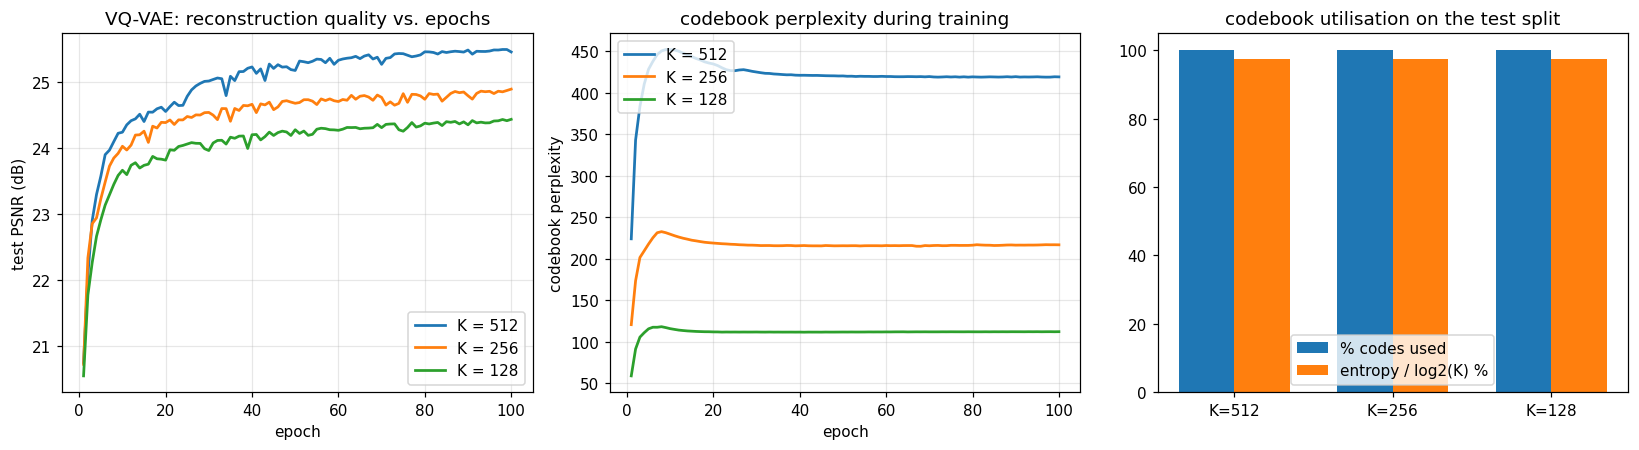

In [16]:
fig, ax = plt.subplots(1, 3, figsize=(15, 4.2))
for K in KS:
    ax[0].plot(range(1, len(vq_hist[K]["psnr"]) + 1), vq_hist[K]["psnr"], label=f"K = {K}", lw=1.8)
    ax[1].plot(range(1, len(vq_hist[K]["perplexity"]) + 1), vq_hist[K]["perplexity"],
               label=f"K = {K}", lw=1.8)
ax[0].set_xlabel("epoch"); ax[0].set_ylabel("test PSNR (dB)")
ax[0].set_title("VQ-VAE: reconstruction quality vs. epochs"); ax[0].legend(); ax[0].grid(alpha=.3)
ax[1].set_xlabel("epoch"); ax[1].set_ylabel("codebook perplexity")
ax[1].set_title("codebook perplexity during training"); ax[1].legend(); ax[1].grid(alpha=.3)

w = 0.35; xi = np.arange(len(KS))
ax[2].bar(xi - w / 2, [vq_stats[K]["usage_pct"]      for K in KS], w, label="% codes used")
ax[2].bar(xi + w / 2, [100 * vq_stats[K]["entropy_ratio"] for K in KS], w, label="entropy / log2(K) %")
ax[2].set_xticks(xi); ax[2].set_xticklabels([f"K={K}" for K in KS])
ax[2].set_title("codebook utilisation on the test split"); ax[2].set_ylim(0, 105); ax[2].legend()
plt.tight_layout(); plt.savefig(RES_DIR / "vqvae_psnr_codebook.png", dpi=150); plt.show()

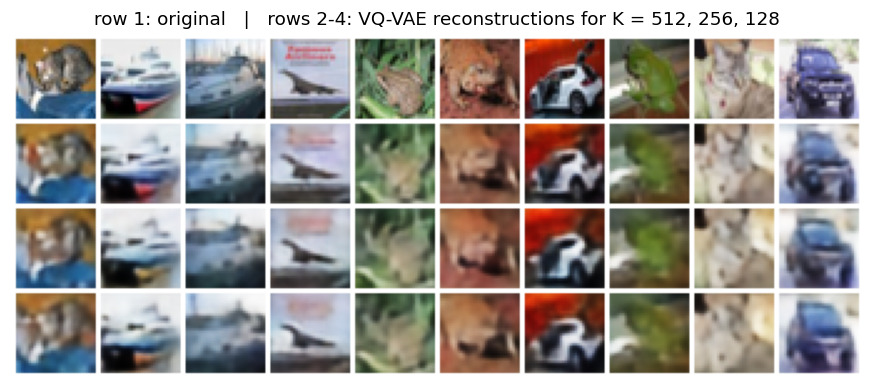

In [17]:
xb   = next(iter(test_loader))[0][:10].to(DEVICE)
rows = [xb.cpu()] + [vq_models[K].reconstruct(xb).cpu() for K in KS]
show_grid(torch.cat(rows), nrow=10, figsize=(10, 4.4),
          title="row 1: original   |   rows 2-4: VQ-VAE reconstructions for K = 512, 256, 128",
          fname="vqvae_reconstructions.png")

### A.2.2 — Extracting the discrete latent maps

Every image is encoded once into its 8×8 grid of codebook indices. These integer maps are the
training data for the PixelCNN prior, so they are computed up-front and cached rather than
re-encoded every epoch.

K=512   train latents (50000, 8, 8) torch.int16   index range [0, 511]
K=256   train latents (50000, 8, 8) torch.int16   index range [0, 255]
K=128   train latents (50000, 8, 8) torch.int16   index range [0, 127]


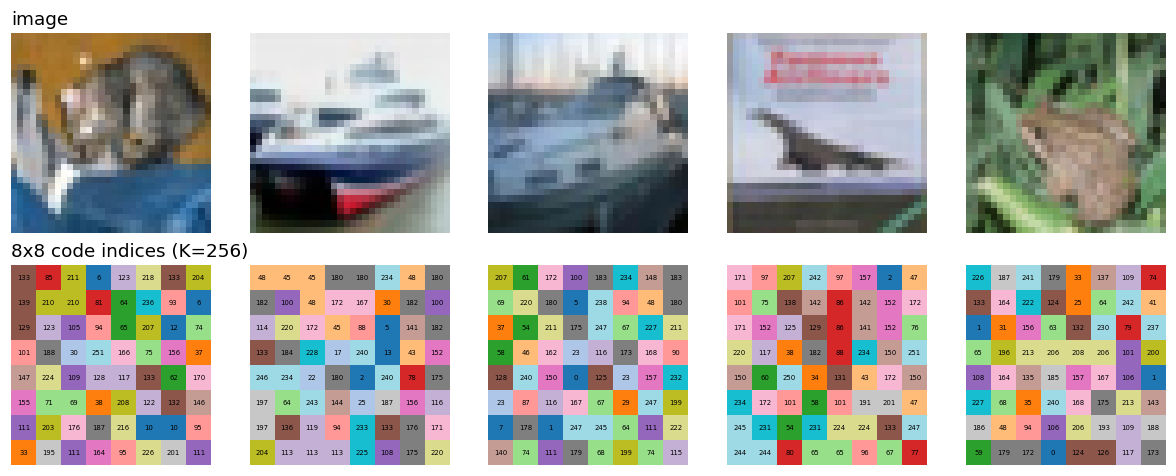

In [18]:
@torch.no_grad()
def extract_latents(model, dataset, bs=500):
    """Encode a dataset into an [N, 8, 8] int16 tensor of codebook indices."""
    model.eval()
    loader = DataLoader(dataset, batch_size=bs, shuffle=False, num_workers=4)
    return torch.cat([model.encode_idx(x.to(DEVICE, non_blocking=True)).cpu().to(torch.int16)
                      for x, _ in loader])


latents = {}
for K in KS:
    f = CKPT_DIR / f"latents_K{K}.pt"
    if f.exists() and not FORCE_RETRAIN:
        latents[K] = torch.load(f, weights_only=True)
    else:
        latents[K] = {"train": extract_latents(vq_models[K], train_set),
                      "test":  extract_latents(vq_models[K], test_set)}
        torch.save(latents[K], f)
    tr = latents[K]["train"]
    print(f"K={K:<4}  train latents {tuple(tr.shape)} {tr.dtype}   "
          f"index range [{int(tr.min())}, {int(tr.max())}]")

# a look at what a latent map actually is
fig, ax = plt.subplots(2, 5, figsize=(11, 4.4))
xb = next(iter(test_loader))[0][:5].to(DEVICE)
ids = vq_models[256].encode_idx(xb).cpu()
for i in range(5):
    ax[0, i].imshow(xb[i].cpu().permute(1, 2, 0).numpy()); ax[0, i].axis("off")
    ax[1, i].imshow(ids[i].numpy(), cmap="tab20"); ax[1, i].axis("off")
    for y in range(8):
        for xx in range(8):
            ax[1, i].text(xx, y, int(ids[i, y, xx]), ha="center", va="center", fontsize=4.5)
ax[0, 0].set_title("image", loc="left"); ax[1, 0].set_title("8x8 code indices (K=256)", loc="left")
plt.tight_layout(); plt.savefig(RES_DIR / "vqvae_latent_maps.png", dpi=150); plt.show()

### A.2.3 — Gated PixelCNN prior over the latents

A **Gated PixelCNN** with separate vertical and horizontal stacks, which removes the blind spot of
the naive masked-convolution PixelCNN. Causality is enforced purely by asymmetric padding plus a
crop:

* the **vertical** stack uses a `(k//2+1) × k` kernel padded by `k//2+1` on top and cropped, so
  position `(i, j)` sees only rows `< i`;
* the **horizontal** stack uses a `1 × (k//2+1)` kernel; in the first layer it is padded by
  `k//2+1` (so it sees only columns `< j` — a "mask A" layer), and in later layers by `k//2`
  (columns `≤ j` — "mask B", which is safe because those features already exclude the current token).

There is an explicit causality test below: perturbing a *future* token must leave the logits at an
earlier position bit-for-bit identical.

In [19]:
def gate(x):
    a, b = x.chunk(2, dim=1)
    return torch.tanh(a) * torch.sigmoid(b)


class GatedMaskedConv(nn.Module):
    def __init__(self, ch, k=3, first=False):
        super().__init__()
        pad = k // 2
        self.first  = first
        self.v_conv = nn.Conv2d(ch, 2 * ch, (pad + 1, k), padding=(pad + 1, pad))
        self.v_to_h = nn.Conv2d(2 * ch, 2 * ch, 1)
        self.h_conv = nn.Conv2d(ch, 2 * ch, (1, pad + 1),
                                padding=(0, pad + 1 if first else pad))
        self.h_out  = nn.Conv2d(ch, ch, 1)

    def forward(self, vx, hx):
        H, W = vx.shape[2], vx.shape[3]
        v = self.v_conv(vx)[:, :, :H, :]          # rows strictly above
        h = self.h_conv(hx)[:, :, :, :W]          # columns to the left
        h = h + self.v_to_h(v)
        ho = self.h_out(gate(h))
        if not self.first:
            ho = ho + hx                          # residual
        return gate(v), ho


class GatedPixelCNN(nn.Module):
    def __init__(self, K, ch=128, n_layers=8):
        super().__init__()
        self.K = K
        self.emb    = nn.Embedding(K, ch)
        self.layers = nn.ModuleList([GatedMaskedConv(ch, 3, first=(i == 0)) for i in range(n_layers)])
        self.head   = nn.Sequential(nn.ReLU(True), nn.Conv2d(ch, 512, 1),
                                    nn.ReLU(True), nn.Conv2d(512, K, 1))

    def forward(self, idx):                       # idx: [B, H, W] long
        x = self.emb(idx).permute(0, 3, 1, 2).contiguous()
        v = h = x
        for layer in self.layers:
            v, h = layer(v, h)
        return self.head(h)                       # [B, K, H, W]

    @torch.no_grad()
    def sample(self, n, hw=8, device=None, temp=1.0):
        device = device or next(self.parameters()).device
        idx = torch.zeros(n, hw, hw, dtype=torch.long, device=device)
        for i in range(hw):
            for j in range(hw):
                logits = self(idx)[:, :, i, j] / temp
                idx[:, i, j] = torch.multinomial(F.softmax(logits, 1), 1).squeeze(1)
        return idx


# ---- causality test: a change at a later position must not affect earlier logits --------------
_p = GatedPixelCNN(16, ch=32, n_layers=4).to(DEVICE).eval()
_a = torch.randint(0, 16, (2, 8, 8), device=DEVICE)
_b = _a.clone(); _b[:, 5, 3] = (_b[:, 5, 3] + 1) % 16          # perturb position (5,3)
with torch.no_grad():
    la, lb = _p(_a), _p(_b)
flat_before = 5 * 8 + 3
diff = (la - lb).abs().flatten(2)                              # [B, K, 64]
past   = diff[:, :, :flat_before + 1].max().item()             # positions <= (5,3) in raster order
future = diff[:, :, flat_before + 1:].max().item()
print(f"max |Δlogits| at positions up to and including (5,3): {past:.3e}   <- must be ~0")
print(f"max |Δlogits| at later positions:                     {future:.3e}   <- must be > 0")
assert past < 1e-6, "PixelCNN is not causal — masking is wrong"
assert future > 0.0, "PixelCNN ignores its input"
print("causality OK")
del _p, _a, _b, la, lb

max |Δlogits| at positions up to and including (5,3): 0.000e+00   <- must be ~0
max |Δlogits| at later positions:                     5.678e-02   <- must be > 0
causality OK


In [20]:
def train_pixelcnn(K, epochs=PCNN_EPOCHS, lr=3e-4, bs=256):
    tag  = f"pixelcnn_K{K}"
    ckpt = CKPT_DIR / f"{tag}.pt"
    if ckpt.exists() and not FORCE_RETRAIN:
        blob  = torch.load(ckpt, map_location=DEVICE, weights_only=False)
        model = GatedPixelCNN(K).to(DEVICE); model.load_state_dict(blob["model"]); model.eval()
        print(f"[{tag}] loaded checkpoint  (test NLL {blob['history']['test_bits'][-1]:.3f} bits/code)")
        return model, blob["history"], blob["train_time_s"]

    set_seed(SEED)
    tr = DataLoader(TensorDataset(latents[K]["train"].long()), batch_size=bs, shuffle=True,
                    drop_last=True, num_workers=2)
    te = DataLoader(TensorDataset(latents[K]["test"].long()),  batch_size=512, shuffle=False)

    model = GatedPixelCNN(K).to(DEVICE)
    opt   = torch.optim.Adam(model.parameters(), lr=lr)
    sched = torch.optim.lr_scheduler.CosineAnnealingLR(opt, T_max=epochs)
    hist  = {"train_bits": [], "test_bits": []}
    t0    = time.time()

    for ep in range(1, epochs + 1):
        model.train(); s = 0.0
        for (z,) in tr:
            z = z.to(DEVICE, non_blocking=True)
            loss = F.cross_entropy(model(z), z)
            opt.zero_grad(set_to_none=True); loss.backward()
            nn.utils.clip_grad_norm_(model.parameters(), 1.0); opt.step()
            s += loss.item()
        sched.step()

        model.eval(); v = 0.0
        with torch.no_grad():
            for (z,) in te:
                z = z.to(DEVICE, non_blocking=True)
                v += F.cross_entropy(model(z), z).item()
        hist["train_bits"].append(s / len(tr) / math.log(2))
        hist["test_bits"].append(v / len(te) / math.log(2))
        if ep % 10 == 0 or ep == 1 or ep == epochs:
            print(f"[{tag}] epoch {ep:3d}/{epochs}  train {hist['train_bits'][-1]:.3f}  "
                  f"test {hist['test_bits'][-1]:.3f} bits/code  (uniform = {math.log2(K):.0f})")

    train_time = time.time() - t0
    model.eval()
    torch.save({"model": model.state_dict(), "history": hist,
                "train_time_s": train_time, "K": K}, ckpt)
    print(f"[{tag}] done in {train_time / 60:.1f} min")
    return model, hist, train_time


pcnn_models, pcnn_hist, pcnn_time = {}, {}, {}
for K in KS:
    pcnn_models[K], pcnn_hist[K], pcnn_time[K] = train_pixelcnn(K)

[pixelcnn_K512] loaded checkpoint  (test NLL 7.419 bits/code)
[pixelcnn_K256] loaded checkpoint  (test NLL 6.667 bits/code)
[pixelcnn_K128] loaded checkpoint  (test NLL 5.815 bits/code)


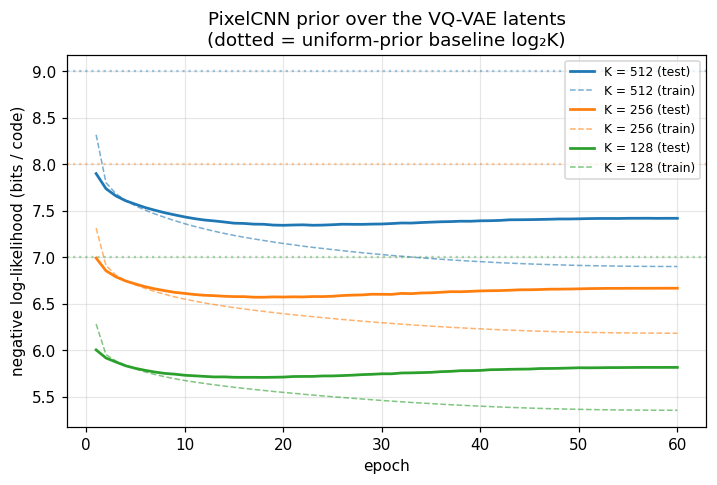

In [21]:
plt.figure(figsize=(7.5, 4.4))
for K in KS:
    e = range(1, len(pcnn_hist[K]["test_bits"]) + 1)
    p = plt.plot(e, pcnn_hist[K]["test_bits"], lw=1.8, label=f"K = {K} (test)")[0]
    plt.plot(e, pcnn_hist[K]["train_bits"], lw=1.0, ls="--", color=p.get_color(), alpha=.6,
             label=f"K = {K} (train)")
    plt.axhline(math.log2(K), color=p.get_color(), ls=":", alpha=.4)
plt.xlabel("epoch"); plt.ylabel("negative log-likelihood (bits / code)")
plt.title("PixelCNN prior over the VQ-VAE latents\n(dotted = uniform-prior baseline log₂K)")
plt.legend(fontsize=8); plt.grid(alpha=.3)
plt.savefig(RES_DIR / "pixelcnn_nll.png", dpi=150); plt.show()

### A.2.4 — Sampling new latent codes, and generating images from them

In [22]:
@torch.no_grad()
def vqvae_sample_bank(K, n=N_FID, bs=500):
    """PixelCNN -> 8x8 code grid -> codebook lookup -> decoder -> images. Returns uint8 + timing."""
    pcnn, vq = pcnn_models[K].eval(), vq_models[K].eval()
    out, t0 = [], time.time()
    for i in range(0, n, bs):
        idx = pcnn.sample(min(bs, n - i))
        out.append(to_uint8(vq.decode_idx(idx)).cpu())
    return torch.cat(out), time.time() - t0


vq_fid, vq_sample_t = {}, {}
for K in KS:
    fake, st = vqvae_sample_bank(K)
    vq_fid[K]      = compute_fid(fake)
    vq_sample_t[K] = st / (len(fake) / 1000)
    s = vq_stats[K]
    log_metric(f"VQ-VAE (K={K})", family="VQ-VAE+PixelCNN", K=K,
               fid=vq_fid[K], psnr=s["psnr"],
               perplexity=s["perplexity"], codes_used=s["codes_used"],
               usage_pct=s["usage_pct"], entropy_bits=s["entropy_bits"],
               codebook_restarts=s["restarts"],
               pixelcnn_test_bits=pcnn_hist[K]["test_bits"][-1],
               params=n_params(vq_models[K]) + n_params(pcnn_models[K]),
               train_time_s=vq_time[K] + pcnn_time[K],
               sample_s_per_1k=vq_sample_t[K])
    print(f"K={K:<4}  FID {vq_fid[K]:7.2f}   recon PSNR {s['psnr']:5.2f} dB   "
          f"perplexity {s['perplexity']:7.1f}   {vq_sample_t[K]:6.2f} s / 1k samples")
    del fake

K=512   FID   88.89   recon PSNR 25.45 dB   perplexity   435.2     4.73 s / 1k samples


K=256   FID   92.84   recon PSNR 24.89 dB   perplexity   221.9     4.60 s / 1k samples


K=128   FID   91.59   recon PSNR 24.43 dB   perplexity   113.5     4.48 s / 1k samples


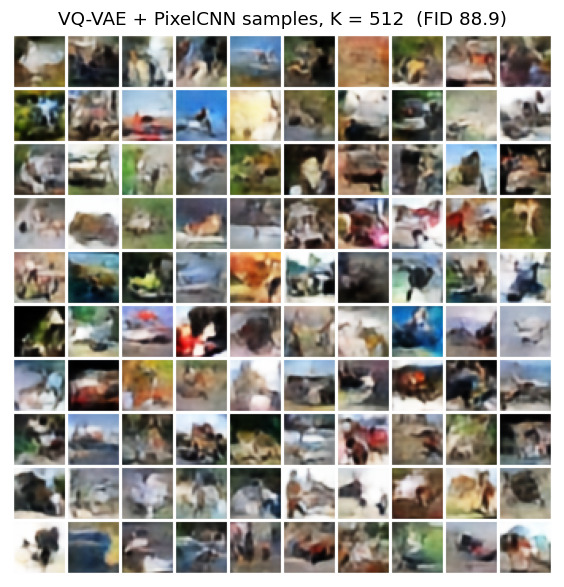

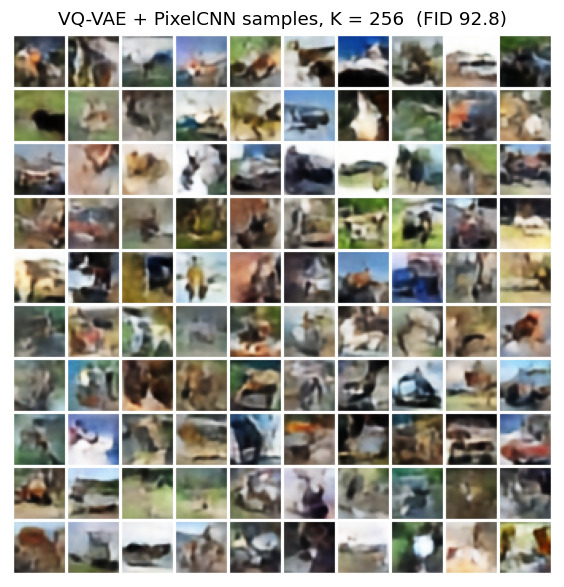

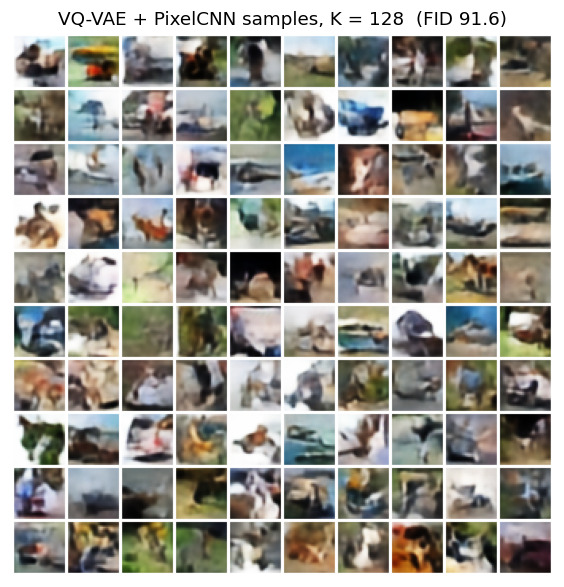

In [23]:
for K in KS:
    set_seed(SEED)
    idx  = pcnn_models[K].sample(100)
    imgs = vq_models[K].decode_idx(idx).cpu()
    show_grid(imgs, nrow=10, figsize=(6.4, 6.4),
              title=f"VQ-VAE + PixelCNN samples, K = {K}  (FID {vq_fid[K]:.1f})",
              fname=f"vqvae_samples_K{K}.png")

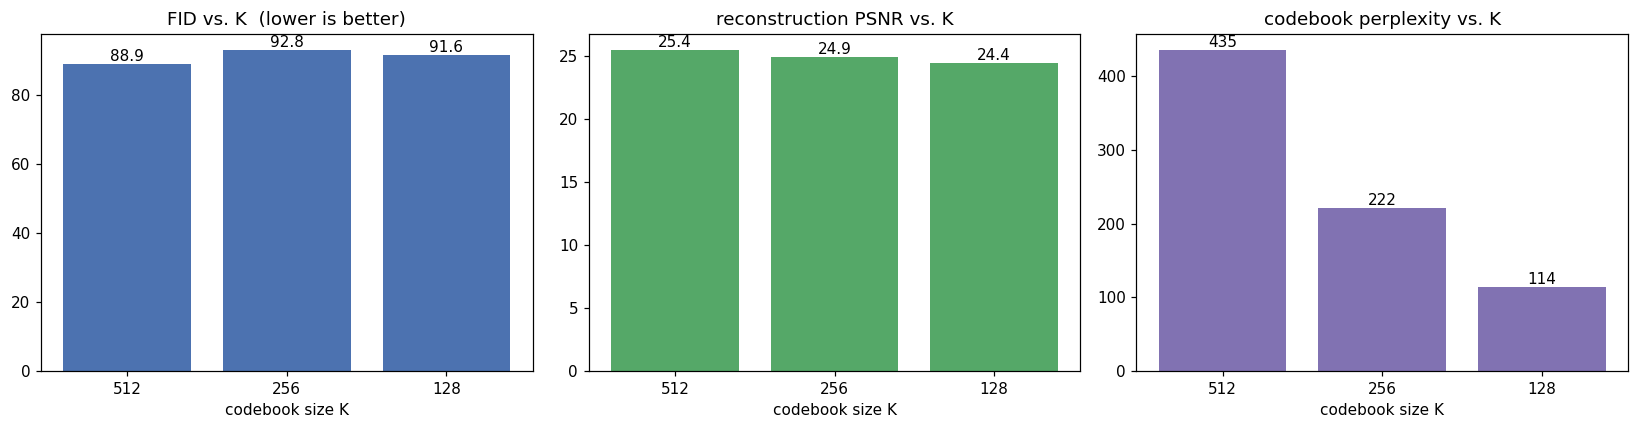

In [24]:
fig, ax = plt.subplots(1, 3, figsize=(15, 4))
xs = [str(K) for K in KS]
for a, vals, t, c in [
    (ax[0], [vq_fid[K] for K in KS],                "FID vs. K  (lower is better)",             "#4C72B0"),
    (ax[1], [vq_stats[K]["psnr"] for K in KS],      "reconstruction PSNR vs. K",                "#55A868"),
    (ax[2], [vq_stats[K]["perplexity"] for K in KS], "codebook perplexity vs. K",               "#8172B2")]:
    a.bar(xs, vals, color=c); a.set_title(t); a.set_xlabel("codebook size K")
    for i, v in enumerate(vals):
        a.text(i, v, f"{v:.1f}" if v < 100 else f"{v:.0f}", ha="center", va="bottom")
plt.tight_layout(); plt.savefig(RES_DIR / "vqvae_fid_psnr_perplexity.png", dpi=150); plt.show()

## A.3 — Part A summary

In [25]:
import pandas as pd

rows = [{"model": f"β-VAE (β={b})", "FID": vae_fid[b], "test PSNR (dB)": vae_psnr_final[b],
         "codebook perplexity": None, "codes used": None,
         "train time (min)": vae_time[b] / 60, "sample s/1k": vae_sample_t[b],
         "params": n_params(vae_models[b])} for b in BETAS]
rows += [{"model": f"VQ-VAE+PixelCNN (K={K})", "FID": vq_fid[K], "test PSNR (dB)": vq_stats[K]["psnr"],
          "codebook perplexity": vq_stats[K]["perplexity"],
          "codes used": f"{vq_stats[K]['codes_used']}/{K}",
          "train time (min)": (vq_time[K] + pcnn_time[K]) / 60,
          "sample s/1k": vq_sample_t[K],
          "params": n_params(vq_models[K]) + n_params(pcnn_models[K])} for K in KS]

df = pd.DataFrame(rows)
df.to_csv(RES_DIR / "partA_summary.csv", index=False)
display(df.style.format({"FID": "{:.2f}", "test PSNR (dB)": "{:.2f}",
                         "codebook perplexity": "{:.1f}", "train time (min)": "{:.1f}",
                         "sample s/1k": "{:.2f}", "params": "{:,}"}, na_rep="—").hide(axis="index"))
print("\nmetrics written to", METRICS_PATH)

model,FID,test PSNR (dB),codebook perplexity,codes used,train time (min),sample s/1k,params
β-VAE (β=1),108.36,23.97,—,—,2.9,0.01,"2,896,516"
β-VAE (β=2),106.54,24.00,—,—,2.9,0.01,"2,896,516"
β-VAE (β=4),107.43,23.86,—,—,2.8,0.01,"2,896,516"
β-VAE (β=10),118.25,22.39,—,—,2.8,0.01,"2,896,516"
VQ-VAE+PixelCNN (K=512),88.89,25.45,435.2,512/512,30.9,4.73,"3,980,611"
VQ-VAE+PixelCNN (K=256),92.84,24.89,221.9,256/256,30.3,4.60,"3,816,515"
VQ-VAE+PixelCNN (K=128),91.59,24.43,113.5,128/128,29.1,4.48,"3,734,467"



metrics written to /datadisk/nishant/M-Tech AI Bits Pilani/sem2/UDL/Assignment2/results/metrics_partA.json


### Discussion of Part A

**β-VAE.** Increasing β tightens the information bottleneck: the KL term decreases monotonically
from 287 to 233, 176 and 89 nats for β = 1, 2, 4 and 10. However, PSNR and FID are nearly flat
and non-monotonic for β = 1, 2 and 4: PSNR is approximately 24.0 dB and FID is 108.4, 106.5 and
107.4 respectively. Clear degradation appears only at β = 10 (22.39 dB PSNR; 118.3 FID).
Therefore β = 1 is used for Part C as specified in the brief. The samples from every β remain
recognisably VAE-like—smooth, low-frequency colour-blob compositions—because the Gaussian
likelihood encourages conditional-mean predictions.

**VQ-VAE.** Reconstruction is far better than any β-VAE (a discrete 8×8×log₂K-bit code with a
straight-through decoder does not pay the KL tax), and it improves mildly with K as the codebook
resolves finer colour and texture distinctions. Codebook utilisation is the interesting axis:
smaller K is used more uniformly (high entropy ratio) while larger K spreads probability mass
thinner, so perplexity rises sub-linearly with K.

**The prior is the bottleneck for sampling.** VQ-VAE *reconstruction* quality does not transfer
to *sample* quality — generated FID is limited by how well the PixelCNN models the 64-token latent
distribution, not by the decoder. This also makes VQ-VAE the slowest sampler by a wide margin: 64
sequential network evaluations per image, against one forward pass for the VAE.